In [ ]:
# Install packages
!pip install swig mediapy tqdm
!pip install mujoco==3.1.4 
!pip install torch torchrl
!pip install gymnasium[box2d,mujoco]==0.28.1

# Imports and Functions

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchrl.data import TensorDictReplayBuffer
from torchrl.data import LazyMemmapStorage
from tensordict import TensorDict
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import mediapy as media
from torchvision.datasets import MNIST
import gymnasium as gym
from tqdm import tqdm


In [2]:
def render_episode(policy, env):
	frames = []
	score = 0
	state = env.reset()[0]
	terminated = truncated = False
	while not terminated and not truncated:
		frame = env.render()
		frames.append(frame)
		action = policy(state)
		state, reward, terminated, truncated, _ = env.step(action)
		score += reward     
	env.close()
	print(f"Finished episode. Cummulative Return: {score}")
	media.show_video(frames, fps=100, loop=True)

# Variational Autoencoders (VAEs)

Variational Autoencoders (VAEs) are a powerful class of generative models that extend the concept of traditional autoencoders, such as denoising autoencoders, by introducing a probabilistic approach to encoding and decoding data. While denoising autoencoders learn to reconstruct clean data from corrupted inputs, VAEs are designed to learn a meaningful, continuous, and structured latent representation of the data, enabling both reconstruction and generation of new samples.

## Key Concepts

- **Probabilistic Latent Space:**  
    Unlike standard autoencoders that map inputs to fixed points in the latent space, VAEs map inputs to a distribution (typically Gaussian) in the latent space. Each input is encoded as a mean and variance, allowing for sampling and generating diverse outputs.

- **Encoder and Decoder:**  
    The encoder network learns to approximate the posterior distribution of the latent variables given the input data. The decoder network reconstructs the input from samples drawn from the latent distribution.

- **Reparameterization Trick:**  
    To enable backpropagation through the stochastic sampling process, VAEs use the reparameterization trick, expressing the sampling operation as a deterministic function of the mean, variance, and a random noise variable.

- **Loss Function:**  
    The VAE loss combines two terms:
    1. **Reconstruction Loss:** Measures how well the decoder reconstructs the input from the latent code (often using binary cross-entropy or mean squared error).
    2. **KL Divergence:** Regularizes the learned latent distribution to be close to a standard normal distribution, encouraging smoothness and continuity in the latent space.

## Why Use VAEs?

- **Generative Modeling:**  
    VAEs can generate new, realistic samples by sampling from the latent space and decoding them, making them useful for tasks like image synthesis and data augmentation.

- **Structured Latent Space:**  
    The regularization encourages the latent space to be continuous and interpretable, allowing for smooth interpolation between data points and meaningful manipulations.

- **Uncertainty Quantification:**  
    By modeling distributions rather than points, VAEs can capture uncertainty in the data and generate diverse outputs.

## Training the VAE

In [50]:
# Load the MNIST dataset
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [77]:
# Define the VAE model. (Comments are for the MNIST dataset, which is 1x28x28)
class VAE(nn.Module):
	def __init__(self, latent_dim, input_shape=(1, 28, 28)):
		super(VAE, self).__init__()
		flatten_dim = 8 * input_shape[1]//4 * input_shape[2]//4
		
		self.encoder = nn.Sequential(
            nn.Conv2d(input_shape[0], 16, kernel_size=3, stride=2, padding=1),#1x28x28 -> 16x14x14
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),#16x14x14 -> 8x7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(flatten_dim, 64),#8x7x7 -> 64
            nn.ReLU(),
            nn.Linear(64, 2*latent_dim)#64 -> 2*latent_dim
        )
		
		self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),#latent_dim -> 64
            nn.ReLU(),
            nn.Linear(64, flatten_dim),#64 -> 8x7x7
            nn.ReLU(),
            nn.Unflatten(1, (8, input_shape[1] // 4, input_shape[2] // 4)), #8x7x7 -> 8x7x7
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),#8x7x7 -> 16x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, input_shape[0], kernel_size=3, stride=2, padding=1, output_padding=1),#16x14x14 -> 1x28x28
            nn.Sigmoid()
        )
		
	def encode(self, x):
		h = self.encoder(x)
		mu, log_var = torch.chunk(h, 2, dim=1)  # Split into mean and log variance
		return mu, log_var
	
	def reparameterize(self, mu, log_var):
		std = torch.exp(0.5 * log_var)
		eps = torch.randn_like(std)
		z = mu + eps * std
		return z
	
	def decode(self, z):
		return self.decoder(z)
	
	def forward(self, x):
		mu, log_var = self.encode(x)
		z = self.reparameterize(mu, log_var)
		x_hat = self.decode(z)
		return x_hat, mu, log_var

# Define the loss function.
def vae_loss(x, x_hat, mu, log_var):
	reconstruction_loss = nn.BCELoss(reduction='sum')(x_hat, x)
	kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
	return reconstruction_loss + kl_divergence



In [87]:
# Initialize VAE model
latent_dim = 2
vae = VAE(latent_dim).to(device)

# Define optimizer
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
	total_loss = 0
	for batch_idx, (data, _) in enumerate(train_loader):
		data = data.to(device)
		
		optimizer.zero_grad()
		recon_batch, mu, log_var = vae(data)
		loss = vae_loss(data, recon_batch, mu, log_var)
		loss.backward()
		total_loss += loss.item()
		optimizer.step()
	
	print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {total_loss/len(train_loader.dataset):.4f}")

Epoch 1/100, Average Loss: 242.5297
Epoch 2/100, Average Loss: 173.0091
Epoch 3/100, Average Loss: 167.6618
Epoch 4/100, Average Loss: 165.0184
Epoch 5/100, Average Loss: 163.2480
Epoch 6/100, Average Loss: 162.0169
Epoch 7/100, Average Loss: 161.0158
Epoch 8/100, Average Loss: 160.2257
Epoch 9/100, Average Loss: 159.5521
Epoch 10/100, Average Loss: 159.0453
Epoch 11/100, Average Loss: 158.5361
Epoch 12/100, Average Loss: 158.0684
Epoch 13/100, Average Loss: 157.7173
Epoch 14/100, Average Loss: 157.3413
Epoch 15/100, Average Loss: 157.0103
Epoch 16/100, Average Loss: 156.6898
Epoch 17/100, Average Loss: 156.4259
Epoch 18/100, Average Loss: 156.2288
Epoch 19/100, Average Loss: 155.9162
Epoch 20/100, Average Loss: 155.7305
Epoch 21/100, Average Loss: 155.4932
Epoch 22/100, Average Loss: 155.2945
Epoch 23/100, Average Loss: 155.1354
Epoch 24/100, Average Loss: 154.9114
Epoch 25/100, Average Loss: 154.7557
Epoch 26/100, Average Loss: 154.6196
Epoch 27/100, Average Loss: 154.4083
Epoch 28/1

## VAE Latent Space

Mean of latent vectors: [0.20487104 0.05377999]
Standard deviation of latent vectors: [0.8536147 1.096434 ]


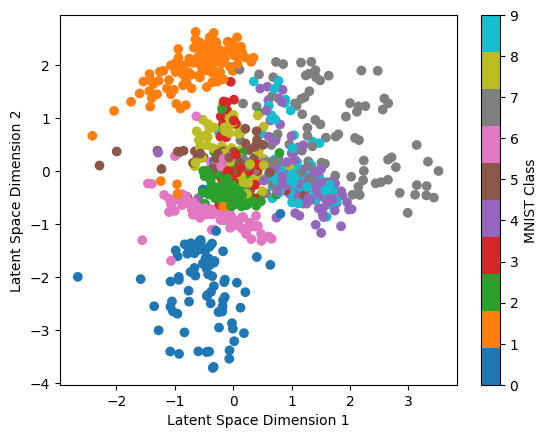

In [88]:
# Get the latent vectors for the first 1000 images in the test set
images = torch.stack([test_dataset[i][0] for i in range(1000)], dim=0)
labels = test_dataset.targets[:1000]
latent_vectors = vae.encode(images.to(dtype=torch.float32,device=device))[0].cpu().detach().numpy()

# Compute mean and standard deviation of the latent vectors
mean_latent = np.mean(latent_vectors, axis=0)
std_latent = np.std(latent_vectors, axis=0)
print(f"Mean of latent vectors: {mean_latent}")
print(f"Standard deviation of latent vectors: {std_latent}")

# Plot the latent spaces with color indicating the classes
plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=labels, cmap='tab10')
plt.colorbar(label='MNIST Class')

# Add labels and title
plt.xlabel('Latent Space Dimension 1')
plt.ylabel('Latent Space Dimension 2')

# Show the plot
plt.show()

## Reconstruction of images from the latent space.

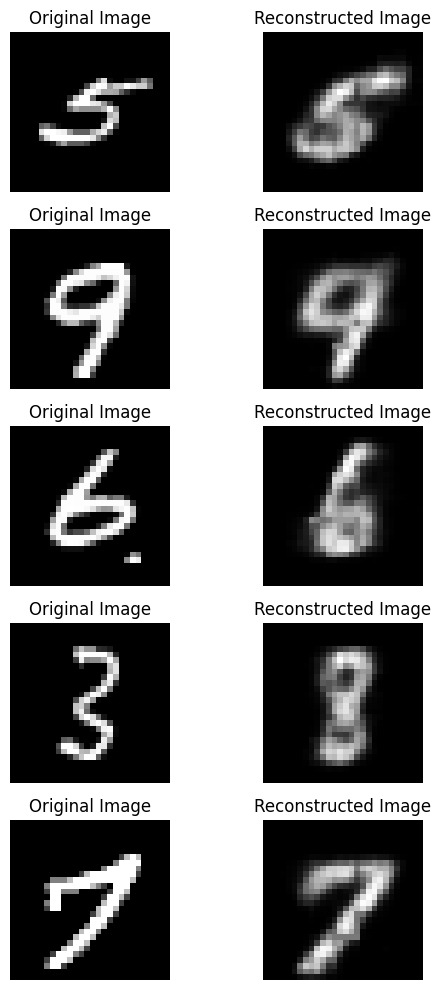

In [89]:
# Set the number of images to denoise and display
num_images = 5

# Denoise and display the images
fig, axes = plt.subplots(num_images, 2, figsize=(6, 10))

for i in range(num_images):
    # Get the original image
    original_image = train_dataset[np.random.randint(0,len(train_dataset))][0].squeeze().numpy()
    
    # Denoise the image using the trained autoencoder
    recreated_image = vae(torch.Tensor(original_image).to(device).view(1, 1, 28, 28))[0].squeeze().cpu().detach().numpy()
    
    # Plot the original and denoised images side by side
    axes[i, 0].imshow(original_image, cmap='gray')
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(recreated_image, cmap='gray')
    axes[i, 1].set_title('Reconstructed Image')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Generation of new images by sampling from the latent space.

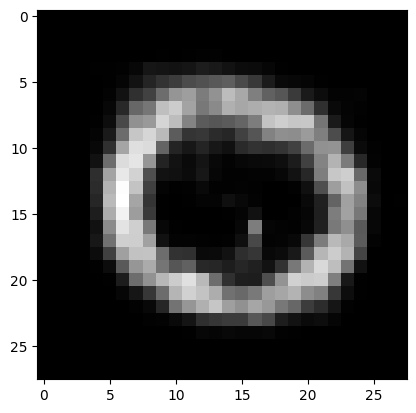

In [92]:
## Solution
# Generate samples from the VAE
latent_vector = torch.randn((1, latent_dim)).to(device)
plt.imshow(vae.decoder(latent_vector).cpu().detach().numpy().squeeze(), cmap='gray')

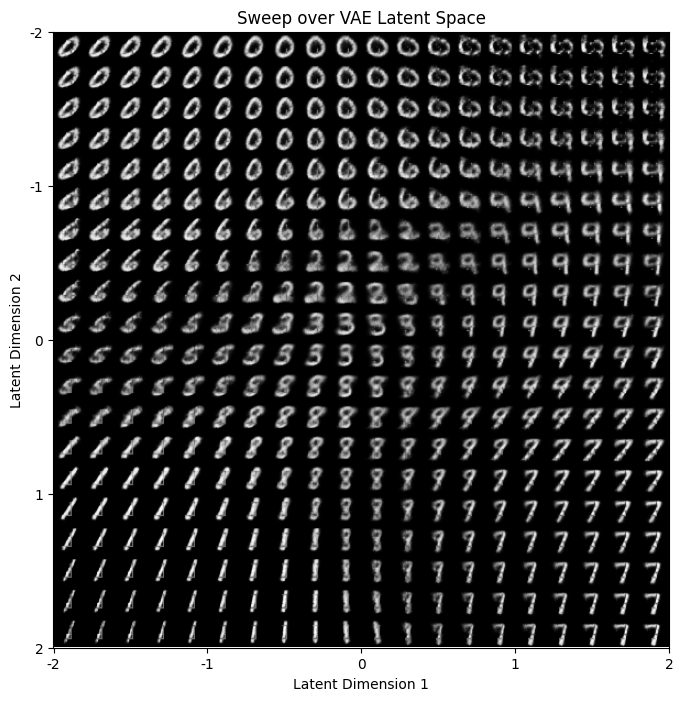

In [91]:
## Solution
# Sweep over the first two dimensions of the latent space.
n = 20  # number of points per axis
extend = 2  # extent of the grid in each direction
grid_x = np.linspace(-extend, extend, n)
grid_y = np.linspace(-extend, extend, n)

figure = np.zeros((28 * n, 28 * n))

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z = torch.tensor([[xi, yi] + [0]*(latent_dim-2)], dtype=torch.float32).to(device)
        with torch.no_grad():
            x_decoded = vae.decode(z).cpu().numpy().squeeze()
        figure[i * 28: (i + 1) * 28,
               j * 28: (j + 1) * 28] = x_decoded

plt.figure(figsize=(8, 8))
plt.imshow(figure, cmap='gray')
plt.title('Sweep over VAE Latent Space')
plt.xticks(np.linspace(0, 28 * n, 5), [str(i) for i in np.linspace(-extend, extend, 5).astype(int)])
plt.yticks(np.linspace(0, 28 * n, 5), [str(i) for i in np.linspace(-extend, extend, 5).astype(int)])
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.show()

### Tasks
1. Compare the latent space representations of the VAE and the denoising autoencoder from the last exercise. What are differences in their structure and distribution?
2. Compare the quality of generated samples (e.g., by sampling random points in latent space) of the VAE and the denoising autoencoder. Which one performs better? Why?
3. Remove the KL divergence term from the VAE loss and observe the effects on the latent space, quality of reconstructed samples and quality of new samples. What does the KL divergence term contribute to the VAE's performance?
4. Experiment with different values of the latent dimension and observe how it affects the quality of the generated and reconstructed samples.

## RL from images
Reinforcement learning from images is a subfield of machine learning that focuses on training agents to make decisions based on visual input. In this approach, the agent directly learns a policy or value function from raw image data, without the need for handcrafted features or explicit state representations. This allows the agent to perceive and understand the environment solely through visual observations.

When it comes to training a reinforcement learning agent from images, there are two main options: using an end-to-end learning algorithm or separating perception and control. 

In end-to-end learning, the agent learns to directly map raw image observations to actions. This approach has the advantage of simplicity and can potentially capture complex relationships between images and actions. However, it often requires a large amount of training data and can be computationally expensive.

On the other hand, separating perception and control involves training separate models for perception (e.g., image recognition) and control (e.g., decision-making). The perception model processes the raw images and extracts relevant features, which are then used as input to the control model. This approach can be more interpretable and efficient, as it allows for leveraging existing image recognition techniques and reduces the dimensionality of the problem. However, it requires careful design and engineering of the perception and control modules.

In summary, the choice between end-to-end learning and separating perception and control depends on the specific requirements of the task and the available resources. End-to-end learning offers simplicity but requires more data and computational resources, while separating perception and control provides interpretability and efficiency but requires additional design and engineering efforts.

In [29]:
# Agent that uses a Deep Q-Network to learn to play the CarRacing-v2 environment from images
class DQNAgent:
	def __init__(self, observation_space, action_space):
		self.observation_space = observation_space
		self.action_space = action_space
		self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
		
		self.q_network = self.build_q_network()
		self.target_network = self.build_q_network()
		self.target_network.load_state_dict(self.q_network.state_dict())
		
		self.q_optimizer = optim.Adam(self.q_network.parameters(), lr=0.0001)
		self.q_loss_fn = nn.MSELoss()
		
		self.batch_size = 128
		self.replay_buffer = TensorDictReplayBuffer(batch_size=self.batch_size, storage=LazyMemmapStorage(1000000))
		self.gamma = 0.99
		self.epsilon = 0.5
		self.epsilon_decay = 0.9999
		self.epsilon_min = 0.01
		self.update_target_interval = 1000
		self.steps_since_last_target_update = 0
	
	def build_q_network(self):
		q_network = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),# 3x96x96 -> 16x48x48
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),# 16x48x48 -> 8x24x24
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8*24*24, 64),#8x24x24 -> 64
            nn.ReLU(),
            nn.Linear(64, self.action_space.n)#64 -> action_space.n
		)
		return q_network.to(self.device)
	
	def act(self, state, explore=False):
		if explore and torch.rand(1) < self.epsilon:
			return self.action_space.sample()
		else:
			with torch.no_grad():
				norm_state = torch.tensor(self.normalize_state(state)).unsqueeze(0).permute(0, 3, 1, 2).to(self.device, torch.float32)
				q_values = self.q_network(norm_state)
				return torch.argmax(q_values, dim=1).to(torch.int64).squeeze().cpu().numpy()

	def store_experience(self, experience: TensorDict):
		self.replay_buffer.add(experience)

	def update(self):
		if len(self.replay_buffer) < self.batch_size:
			return

		batch = self.replay_buffer.sample(self.batch_size)
		states = batch['pixels'].to(self.device)
		actions = batch['action'].to(self.device)
		rewards = batch['reward'].to(self.device)
		next_states = batch['next_pixels'].to(self.device)
		dones = batch['done'].to(self.device)

		norm_states = self.normalize_state(states).to(self.device,torch.float32).permute(0, 3, 1, 2)
		norm_next_states = self.normalize_state(next_states).to(self.device,torch.float32).permute(0, 3, 1, 2)

		q_values = self.q_network(norm_states).gather(1, actions.unsqueeze(1))
		with torch.no_grad():
			next_q_values = self.target_network(norm_next_states).max(1)[0]
		target_q_values = rewards + self.gamma * next_q_values * (1 - dones)
		
		loss = self.q_loss_fn(q_values, target_q_values.unsqueeze(1))
		
		self.q_optimizer.zero_grad()
		loss.backward()
		self.q_optimizer.step()
		
		self.steps_since_last_target_update += 1
		if self.steps_since_last_target_update >= self.update_target_interval:
			self.target_network.load_state_dict(self.q_network.state_dict())
			self.steps_since_last_target_update = 0

		if self.epsilon > self.epsilon_min:
			self.epsilon *= self.epsilon_decay
	
	def normalize_state(self, state):
		# Normalize the state to [0, 1]
		return state / 255.0


In [30]:

# Define the training parameters
num_episodes = 100
max_steps_per_episode = 1000

# Initialize the environment and agent
env = gym.make('CarRacing-v3', continuous=False)
dqn_agent = DQNAgent(env.observation_space, env.action_space)

# Track episode rewards
episode_rewards_image_dqn = []

# Training loop
for episode in range(num_episodes):
	state = env.reset()[0]
	episode_reward = 0

	pbar = tqdm(range(max_steps_per_episode), leave=True)
	for step in pbar:
		pbar.set_description(f"Episode {episode+1:>3}/{num_episodes} - Reward: {episode_reward:>10.2f}, Epsilon: {dqn_agent.epsilon:<.4f}")
		# Choose an action based on the current state
		action = dqn_agent.act(state, explore=True)

		# Take the chosen action in the environment
		next_state, reward, terminal, truncated, _ = env.step(action)

		# Store the experience in the agent's replay buffer
		tensordict = TensorDict({'pixels': torch.tensor(state).to(torch.float32),
								 'action': torch.tensor(action).to(torch.int64),
								 'reward': torch.tensor(reward).to(torch.float32),
								 'next_pixels': torch.tensor(next_state).to(torch.float32),
								 'done': torch.tensor(terminal or truncated).to(torch.float32)
								 })
		dqn_agent.store_experience(tensordict)

		# Update the agent's Q-network
		dqn_agent.update()

		# Update the current state and episode reward
		state = next_state
		episode_reward += float(reward)

		if terminal or truncated:
			break

	episode_rewards_image_dqn.append(episode_reward)


Episode   1/100 - Reward:       6.23, Epsilon: 0.5000:   0%|          | 0/1000 [00:00<?, ?it/s]

Episode   1/100 - Reward:     -56.13, Epsilon: 0.4582: 100%|█████████▉| 999/1000 [00:11<00:00, 89.38it/s] 
Episode   2/100 - Reward:     -56.56, Epsilon: 0.4146: 100%|█████████▉| 999/1000 [00:11<00:00, 83.42it/s]
Episode   3/100 - Reward:     -61.44, Epsilon: 0.3752: 100%|█████████▉| 999/1000 [00:12<00:00, 82.59it/s]
Episode   4/100 - Reward:     -36.15, Epsilon: 0.3395: 100%|█████████▉| 999/1000 [00:11<00:00, 84.51it/s]
Episode   5/100 - Reward:     -31.17, Epsilon: 0.3072: 100%|█████████▉| 999/1000 [00:11<00:00, 83.99it/s]
Episode   6/100 - Reward:     -43.12, Epsilon: 0.2779: 100%|█████████▉| 999/1000 [00:12<00:00, 81.35it/s]
Episode   7/100 - Reward:     -31.31, Epsilon: 0.2515: 100%|█████████▉| 999/1000 [00:11<00:00, 86.24it/s]
Episode   8/100 - Reward:     -51.36, Epsilon: 0.2275: 100%|█████████▉| 999/1000 [00:12<00:00, 81.84it/s]
Episode   9/100 - Reward:     -24.90, Epsilon: 0.2059: 100%|█████████▉| 999/1000 [00:12<00:00, 82.16it/s]
Episode  10/100 - Reward:     -21.67, Epsilon

In [76]:
# Render an episode using the trained agent
render_episode(dqn_agent.act, gym.make('CarRacing-v3', continuous=False, render_mode='rgb_array'))

Finished episode. Cummulative Return: 167.6056338028219


This browser does not support the video tag.


### Tasks:
1. Use a VAE to transform the high dimensional image input to a low dimensional latent state and use DQN to learn from this latent state. Which algorithm converges faster? Which is more stable?
2. Play around with the latent space of the VAE. Are there relevant directions in the latent space that correspond to specific actions or behaviors in the environment? To investigate this, you could for example plot values of the latent state next to the video of the environment.
3. What problems do you see when using a VAE to transform the high dimensional image input to a low dimensional latent state and using DQN to learn from this latent state? How can you address these issues?
4. (Homework, advanced) We here used a VAE to transform the high dimensional image input to a low dimensional latent state and used DQN to learn from this latent state. There are more sophisticated approaches to using latent spaces in RL. One popular approach is to use latent world models. These models learn a latent representation of the environment and can be used to plan actions in this latent space or learn policies from internal simulations. One of the most popular algorithms for this is called [Dreamer](https://arxiv.org/abs/2301.04104). Read the paper and implement the algorithm in a simple environment. Since you may not want to implement everything from scratch, we recommend using modules from [torchrl](https://pytorch.org/rl/).

In [32]:
## Solution
LATENT_DIM = 8
class VAEDQNAgent(DQNAgent):
	def __init__(self, observation_space, action_space):
		super(VAEDQNAgent, self).__init__(observation_space, action_space)
		self.vae = self.build_vae()
		self.vae_loss_fn = vae_loss
		self.vae_optimizer = optim.Adam(self.vae.parameters(), lr=0.0001)
		self.update_vae_interval = 1
		self.update_vae_batches = 1
		self.steps_since_last_vae_update = 0

	def build_vae(self):
		return VAE(LATENT_DIM, input_shape=(3, 96, 96)).to(self.device)

	def build_q_network(self):
		q_network = nn.Sequential(
			nn.Linear(LATENT_DIM, 128),
			nn.ReLU(),
			nn.Linear(128, 128),
			nn.ReLU(),
			nn.Linear(128, self.action_space.n)
		)
		return q_network.to(self.device)

	def update(self):
		if self.steps_since_last_vae_update >= self.update_vae_interval:
			self.steps_since_last_vae_update = 0
			for _ in range(self.update_vae_batches):
				self.update_vae()
		else:
			self.steps_since_last_vae_update += 1
		self.update_dqn()

	def update_vae(self):
		if len(self.replay_buffer) < self.batch_size:
			return

		batch = self.replay_buffer.sample(self.batch_size)
		states = batch['pixels'].to(self.device)
		states_norm = self.normalize_state(states).to(self.device).to(torch.float32).permute(0, 3, 1, 2)

		# Encode states using VAE
		mu, log_var = self.vae.encode(states_norm)
		z = self.vae.reparameterize(mu, log_var)
		
		reconstructed_states = self.vae.decode(z)

		loss = self.vae_loss_fn(states_norm, reconstructed_states, mu, log_var)

		self.vae_optimizer.zero_grad()
		loss.backward()
		self.vae_optimizer.step()

	def update_dqn(self):
		if len(self.replay_buffer) < self.batch_size:
			return

		batch = self.replay_buffer.sample(self.batch_size)
		states = batch['pixels'].to(self.device)
		actions = batch['action'].to(self.device)
		rewards = batch['reward'].to(self.device)
		next_states = batch['next_pixels'].to(self.device)
		dones = batch['done'].to(self.device)

		states_norm = self.normalize_state(states).to(self.device).to(torch.float32).permute(0, 3, 1, 2)
		next_states_norm = self.normalize_state(next_states).to(self.device).to(torch.float32).permute(0, 3, 1, 2)

		# Encode states and next_states using VAE
		with torch.no_grad():
			latent_states = self.vae.encode(states_norm)[0]
			latent_next_states = self.vae.encode(next_states_norm)[0]

		q_values = self.q_network(latent_states).gather(1, actions.unsqueeze(1))
		next_q_values = self.target_network(latent_next_states).max(1)[0].detach()
		target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

		loss = self.q_loss_fn(q_values, target_q_values.unsqueeze(1))

		self.q_optimizer.zero_grad()
		loss.backward()
		self.q_optimizer.step()

		self.steps_since_last_target_update += 1
		if self.steps_since_last_target_update >= self.update_target_interval:
			self.target_network.load_state_dict(self.q_network.state_dict())
			self.steps_since_last_target_update = 0

		if self.epsilon > self.epsilon_min:
			self.epsilon *= self.epsilon_decay

	def act(self, state, explore=False):
		if explore and torch.rand(1) < self.epsilon:
			return self.action_space.sample()
		else:
			with torch.no_grad():
				state_norm = torch.tensor(self.normalize_state(state)).unsqueeze(0).permute(0, 3, 1, 2).to(self.device, torch.float32)
				latent_vector = self.vae.encode(state_norm)[0]
				q_values = self.q_network(latent_vector)
				return torch.argmax(q_values, dim=1).squeeze().cpu().numpy()

In [33]:
## Solution
# Define the training parameters
num_episodes = 100
max_steps_per_episode = 1000

# Initialize the environment and agent
env = gym.make('CarRacing-v3', continuous=False)
vae_dqn_agent = VAEDQNAgent(env.observation_space, env.action_space)

# Track episode rewards
episode_rewards_vae_dqn = []

# Training loop
for episode in range(num_episodes):
	state = env.reset()[0]
	episode_reward = 0
	
	pbar = tqdm(range(max_steps_per_episode), leave=True)
	for step in pbar:
		pbar.set_description(f"Episode {episode+1:>3}/{num_episodes} - Reward: {episode_reward:>10.2f}, Epsilon: {vae_dqn_agent.epsilon:<.4f}")
		# Choose an action based on the current state
		action = vae_dqn_agent.act(state, explore=True)

		# Take the chosen action in the environment
		next_state, reward, terminal, truncated, _ = env.step(action)

		# Store the experience in the agent's replay buffer
		tensordict = TensorDict({'pixels': torch.tensor(state).to(torch.float32),
								 'action': torch.tensor(action).to(torch.int64),
								 'reward': torch.tensor(reward).to(torch.float32),
								 'next_pixels': torch.tensor(next_state).to(torch.float32),
								 'done': torch.tensor(terminal or truncated).to(torch.float32)
								 })	
		vae_dqn_agent.store_experience(tensordict)
		
		# Update the agent's Q-network
		vae_dqn_agent.update()
		
		# Update the current state and episode reward
		state = next_state
		episode_reward += float(reward)

		if terminal or truncated:
			break

	episode_rewards_vae_dqn.append(episode_reward)
	

Episode   1/100 - Reward:     -12.28, Epsilon: 0.4919:  29%|██▉       | 289/1000 [00:02<00:10, 64.96it/s] 

Episode   1/100 - Reward:     -73.14, Epsilon: 0.4582: 100%|█████████▉| 999/1000 [00:13<00:00, 71.54it/s]
Episode   2/100 - Reward:     -58.23, Epsilon: 0.4146: 100%|█████████▉| 999/1000 [00:15<00:00, 66.00it/s]
Episode   3/100 - Reward:      12.28, Epsilon: 0.3752: 100%|█████████▉| 999/1000 [00:15<00:00, 64.20it/s]
Episode   4/100 - Reward:     -76.41, Epsilon: 0.3395: 100%|█████████▉| 999/1000 [00:14<00:00, 66.62it/s]
Episode   5/100 - Reward:     -44.34, Epsilon: 0.3072: 100%|█████████▉| 999/1000 [00:15<00:00, 64.80it/s]
Episode   6/100 - Reward:     -45.59, Epsilon: 0.2779: 100%|█████████▉| 999/1000 [00:15<00:00, 64.65it/s]
Episode   7/100 - Reward:     -24.09, Epsilon: 0.2515: 100%|█████████▉| 999/1000 [00:15<00:00, 65.63it/s]
Episode   8/100 - Reward:     -22.16, Epsilon: 0.2275: 100%|█████████▉| 999/1000 [00:15<00:00, 65.63it/s]
Episode   9/100 - Reward:       3.22, Epsilon: 0.2059: 100%|█████████▉| 999/1000 [00:15<00:00, 65.73it/s]
Episode  10/100 - Reward:     -60.56, Epsilon:

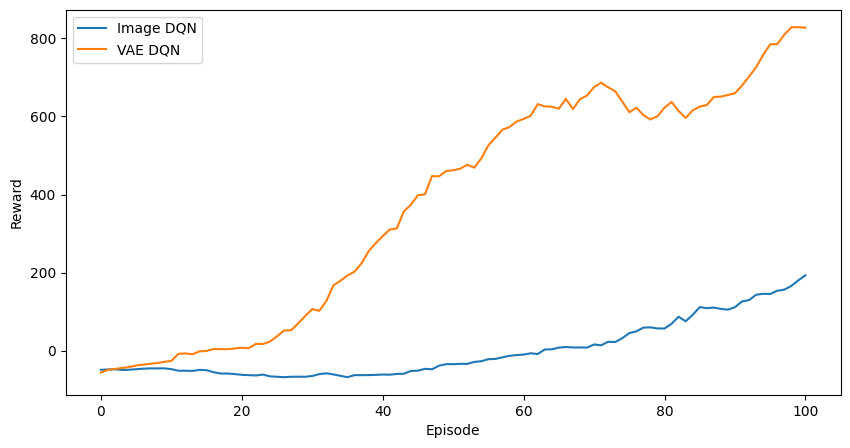

In [ ]:
## Solution
# Plot the moving average of the episode rewards for both agents.
def moving_average(x, window=20):
	x_padded = np.pad(x, (window//2, window//2), mode='edge')
	return np.convolve(x_padded, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_average(episode_rewards_image_dqn), label='Image DQN')
plt.plot(moving_average(episode_rewards_vae_dqn), label='VAE DQN')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.show()

In [ ]:
## Solution
# Run one episode and collect frames, latent states, and reconstructions
max_steps = max_steps_per_episode
frames = np.empty((max_steps, *env.observation_space.shape), dtype=np.uint8)
latents = np.empty((max_steps, vae_dqn_agent.vae.encoder[-1].out_features // 2), dtype=np.float32)
recons = np.empty_like(frames, dtype=np.uint8)

state = env.reset()[0]
reward_sum = 0.
done = False
step = 0
while not done and step < max_steps:
	frames[step] = state
	state_norm = torch.tensor(vae_dqn_agent.normalize_state(state)).unsqueeze(0).permute(0, 3, 1, 2).to(vae_dqn_agent.device, torch.float32)
	with torch.no_grad():
		mu, _ = vae_dqn_agent.vae.encode(state_norm)
		latent = mu.cpu().numpy().squeeze()
		latents[step] = latent
		recon = vae_dqn_agent.vae.decode(mu).cpu().numpy().squeeze().transpose(1, 2, 0)
		recon = np.clip(recon * 255, 0, 255).astype(np.uint8)
		recons[step] = recon
	action = vae_dqn_agent.act(state)
	state, reward, done, truncated, _ = env.step(action)
	reward_sum += float(reward)
	done = done or truncated
	step += 1

frames = frames[:step]
latents = latents[:step]
recons = recons[:step]

# Print the total reward for the episode
print(f"Total reward for the episode: {reward_sum}")

# Stack environment, reconstruction, and latent visualization frames
video_frames = []
for i in range(len(frames)):
	fig, axes = plt.subplots(1, 3, figsize=(12, 4))
	axes[0].imshow(frames[i])
	axes[0].set_title("Environment")
	axes[0].axis('off')
	axes[1].imshow(recons[i])
	axes[1].set_title("VAE Reconstruction")
	axes[1].axis('off')
	if latents.shape[1] == 2:
		axes[2].scatter(latents[:,0], latents[:,1], c='gray', alpha=0.3)
		axes[2].scatter(latents[i,0], latents[i,1], c='red')
		axes[2].set_xlim(latents[:,0].min()-1, latents[:,0].max()+1)
		axes[2].set_ylim(latents[:,1].min()-1, latents[:,1].max()+1)
		axes[2].set_title("Latent State (2D)")
	else:
		axes[2].bar(np.arange(latents.shape[1]), latents[i])
		axes[2].set_ylim(latents.min(), latents.max())
		axes[2].set_title("Latent State")
	plt.tight_layout()
	fig.canvas.draw()
	# Convert to numpy array
	img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
	img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))[..., :3]  # Drop alpha channel
	video_frames.append(img)
	plt.close(fig)
media.show_video(video_frames, fps=20, loop=False)


Total reward for the episode: 831.1475409835969


This browser does not support the video tag.
